FIRST FIVE ROWS
  Rank       Country  Proven_reserves  Production  Consumption    Exports  \
0    1     Venezuela     298350000000   3023000.0     571000.0  2452000.0   
1    2  Saudi Arabia     267900000000   9684700.0    2817000.0  6880000.0   
2    3        Canada     173100000000   3324300.0    2259000.0  1576000.0   
3    4          Iran     154600000000   3113300.0    1709000.0  2445000.0   
4    5          Iraq     141400000000   3054400.0     818000.0  2390000.0   

    Imports  
0       0.0  
1       0.0  
2  770300.0  
3   15600.0  
4       0.0  

Dataset Shape:
(210, 7)

Column Names:
Index(['Rank', 'Country', 'Proven_reserves', 'Production', 'Consumption',
       'Exports', 'Imports'],
      dtype='object')

Data Types:
Rank                object
Country             object
Proven_reserves      int64
Production         float64
Consumption        float64
Exports            float64
Imports            float64
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFra

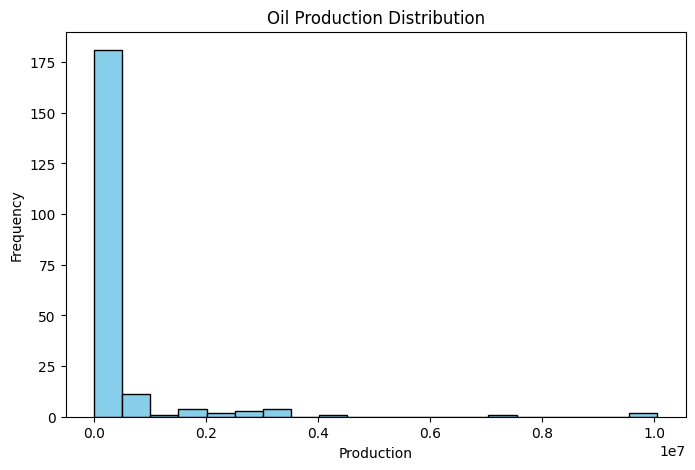

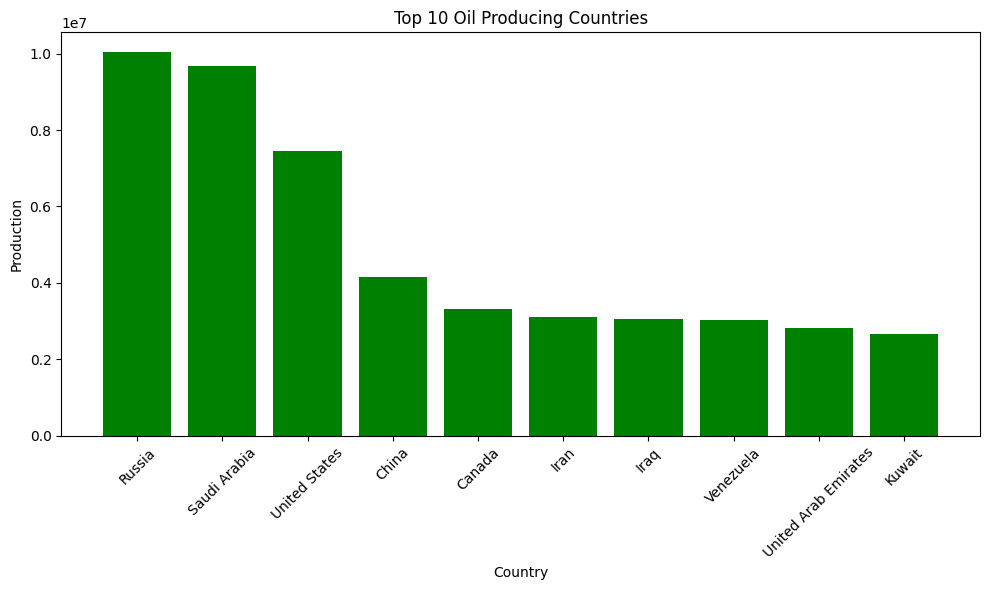

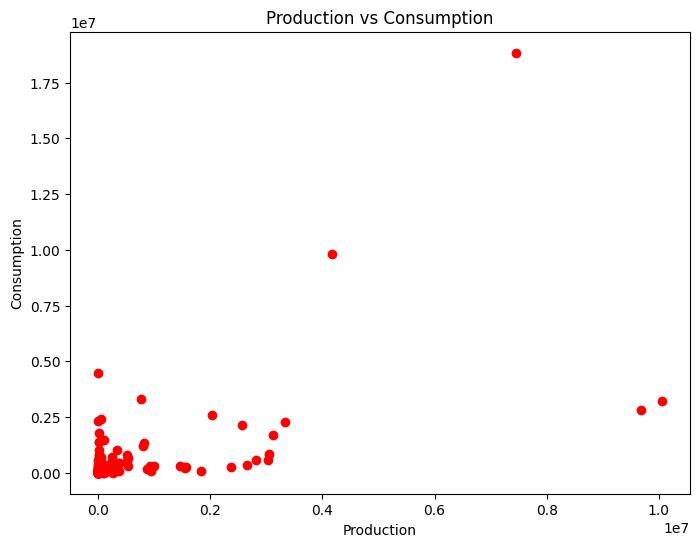

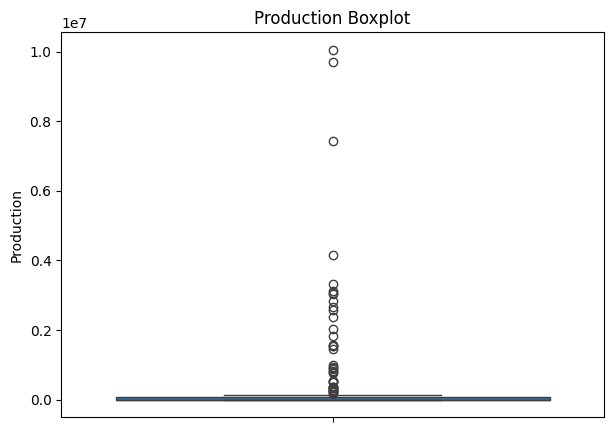

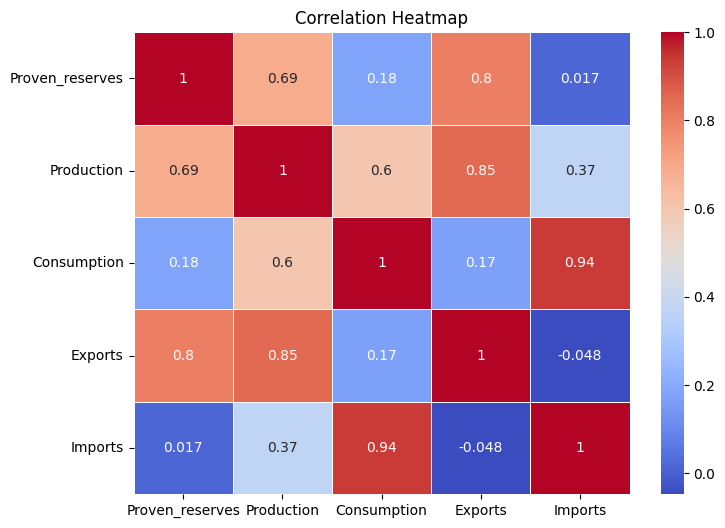


EDA Completed Successfully!


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option('display.max_columns', None)


df = pd.read_csv("/content/oil_by_country.csv")
df.columns = df.columns.str.strip()

print("=================================")
print("FIRST FIVE ROWS")
print("=================================")
print(df.head())



print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())


df = df.drop_duplicates()


numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())


print("\nDescriptive Statistics")
print(df.describe())

print("\nCountries with Production > 1000")
high_production = df[df['Production'] > 1000]
print(high_production[['Country', 'Production']])


if 'Region' in df.columns:
    print("\nAverage Oil Production by Region")
    region_avg = df.groupby('Region')['Production'].mean()
    print(region_avg)



print("\nCorrelation Matrix")
correlation = df.corr(numeric_only=True)
print(correlation)




plt.figure(figsize=(8,5))
plt.hist(df['Production'], bins=20, color='skyblue', edgecolor='black')
plt.title("Oil Production Distribution")
plt.xlabel("Production")
plt.ylabel("Frequency")
plt.show()

top10 = df.sort_values(by='Production', ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.bar(top10['Country'], top10['Production'], color='green')
plt.xticks(rotation=45)
plt.title("Top 10 Oil Producing Countries")
plt.xlabel("Country")
plt.ylabel("Production")
plt.tight_layout()
plt.show()


plt.figure(figsize=(8,6))
plt.scatter(df['Production'], df['Consumption'], color='red')
plt.title("Production vs Consumption")
plt.xlabel("Production")
plt.ylabel("Consumption")
plt.show()


plt.figure(figsize=(7,5))
sns.boxplot(y=df['Production'])
plt.title("Production Boxplot")
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(correlation,
            annot=True,
            cmap='coolwarm',
            linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()


if 'Reserves' in df.columns:
    print("\nTop 5 Countries by Oil Reserves")
    print(df[['Country', 'Reserves']]
          .sort_values(by='Reserves', ascending=False)
          .head())

print("\nEDA Completed Successfully!")